<a href="https://colab.research.google.com/github/dipikamishra/my-repository/blob/main/Answers_02_DataPreparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preparation

In this week's practical we will learn and practice the following skills:
- Load and explore a data set using Pandas
- Identify data quilaity issues
- Handle missing data of various types (numerical, categorical)
- Detect and handle duplicate data
- Data type conversion
- Detect and describe data distributions
- Normalise data
- Encode categorical data
- Create a pipeline
- Documenting our data preparation work

## Preparing your workspace
In this practical we'll be using Python/[Pandas](https://pandas.pydata.org) to explore and visualise some example data using [Jupyter Notebooks](https://jupyter.org) in [Google Colaboratory](https://colab.research.google.com).

At the start of each practical you should make a copy of the notebook in your own google drive:
- File -> Save as copy in Drive

If you would prefer to work with a Jupyter Lab session ony your own machine you can download the notebook directly via:
- File -> Downaload -> Download .ipynb

In this practial we will be preparing data for use with some data mining applications.

The data for this week can be found on [GitHub](https://github.com/PaulHancock/COMP5009_pracs).


## Titanic revisited

Last week we explored the titanic manifest dataset using SQL.
This week we'll start by re-doing much of this exploration as we learn to use python, pandas, and jupyter notebooks.

Complete the following tasks:
1. Load the data file [titanic.csv](https://raw.githubusercontent.com/PaulHancock/COMP5009_pracs/main/data/titanic.csv) from GitHub.
2. Display the first 10 rows of the dataset.
3. Examine the column names and content and determine an appropriate data type for each.
  - Look at the data types used by pandas and comment on any differences
4. Is the data multidimensional?  
  - Find the number of attributes and the number of instances.
5. For each attribute:
  - check if there are any missing entries
  - Find the min, max, avg, sum values if relevant
  - Plot a histogram of the data
6. Select all the passengers with "Dr." in their name.
  - Group these data by sex
7. Compute the average fare grouped by class and embarkation port.
  

In [ ]:
# Load the modules that we'll be using
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
# np, pd, and plt are common shorthands for these often used modules

### 1. Load the data
Load the data into a pandas data frame

In [ ]:
# The data are hosted in github and we can load it directly from the URL
data_url = 'https://raw.githubusercontent.com/PaulHancock/COMP5009_pracs/main/data/titanic.csv'
df = pd.read_csv(data_url)

In [ ]:
# view the loaded data to make sure that it makes sense
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 2. Display the first 10 rows
We can make use of the `.head()` method provided by the data frame.
Try also:
- df.head(5)
- df.tail()

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Examine the data
Examine the column names and content and determine an appropriate data type for each.
  - Look at the data types used by pandas and comment on any differences

In [ ]:
print("Column Name | Data type")
print(df.dtypes)

Column Name | Data type
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


Some of the coulumns are listed as "object" type,  which in this case means they are stored as strings. However, some of the strings (like Sex and Embarked) are drawn from a restricted set, and thus should be considered categorical data.

Additionally, we note that some of the numeric columns (Survived and PClass) have values drawn from a restricted set, so they should be categorical as well.

Use `df[<colname>].astype('category')` to change the Sex and Embarked columns into categorical data, and then print `df[<colname>].cat.categories` to see what categories are present in each.

In [ ]:
for col in ['Sex', 'Embarked', 'Pclass', 'Survived']:
  df[col] = df[col].astype('category')
  print(f"\nCategories for '{col}': {df[col].cat.categories}")


Categories for 'Sex': Index(['female', 'male'], dtype='object')

Categories for 'Embarked': Index(['C', 'Q', 'S'], dtype='object')

Categories for 'Pclass': Index([1, 2, 3], dtype='int64')

Categories for 'Survived': Index([0, 1], dtype='int64')


### 4. Is the data multidimensional?  
Find the number of attributes and the number of instances.

In [ ]:
# the shape attribute will show the number of (rows, columns)
df.shape

(891, 12)

### 5. Summarise the data
For each attribute:
  - check if there are any missing entries
  - Find the min, max, avg, sum values if relevant
  - Plot a histogram of the data

In [ ]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# if we run a funciton on the data frame it runs on ech column.
# `numeric_only=True` means that we ignore the text columns
df.sum(numeric_only=True)

,0
PassengerId,397386.0000
Age,21205.1700
SibSp,466.0000
Parch,340.0000
Fare,28693.9493


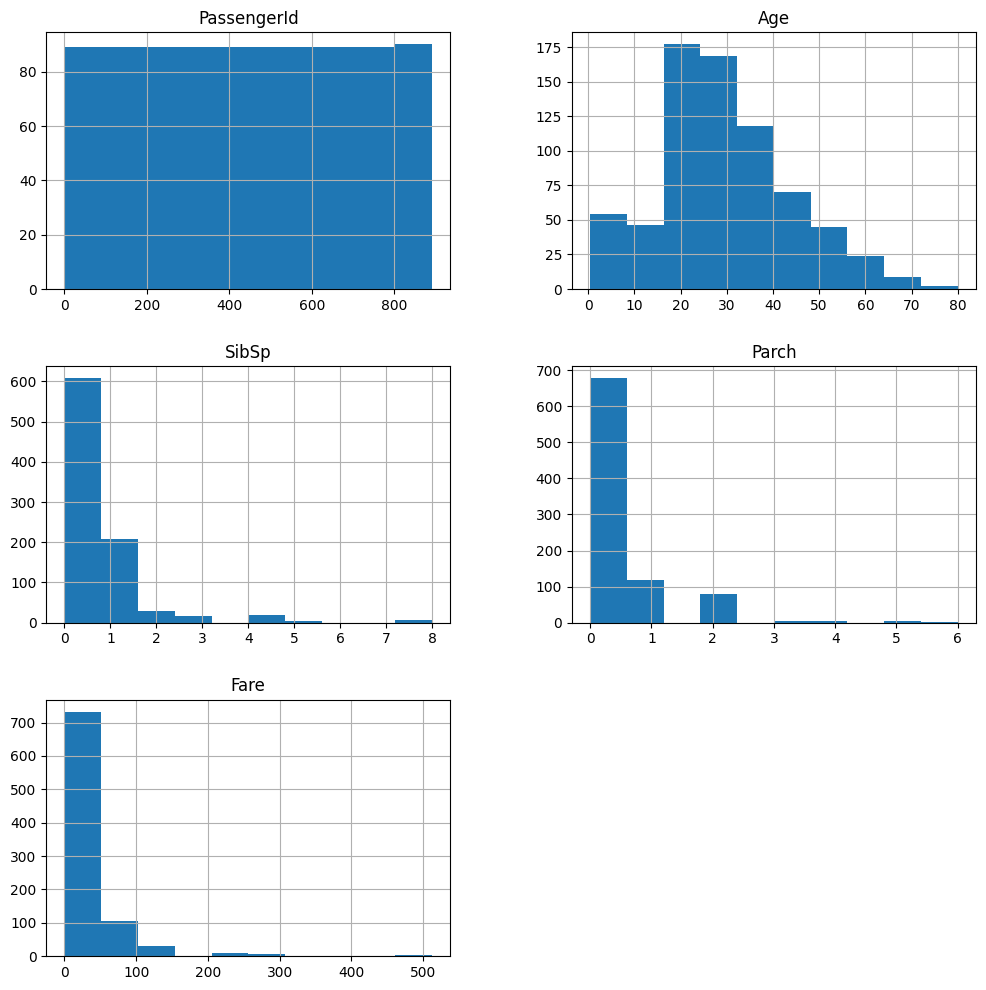

In [ ]:
# We can plot a histogram of all the data together
df.hist(figsize=(12,12))
plt.show()

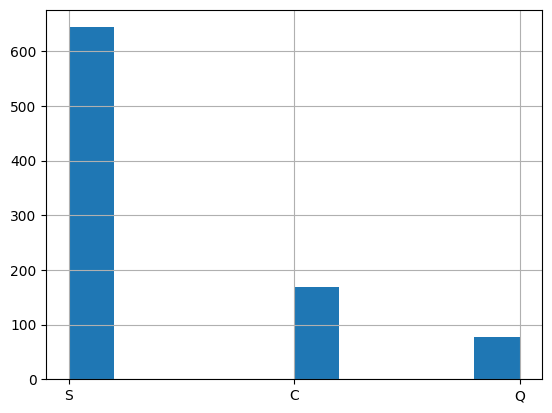

In [ ]:
# or one by one, even for categorical data
df['Embarked'].hist()
plt.show()

### 6. Find the doctors
Select all the passengers with "Dr." in their name.
- Group these data by sex

In [ ]:
# in sql we have a filter using the WHERE clause to select our data
filter = df['Name'].str.contains('Dr\.')
doctors = df[filter]
# then we GROUP BY, and then we run the count() command
# there is no pandas equivalent of count(*) so we have to run count on a column with no NULLs
doctors.groupby('Sex').count()

/tmp/ipython-input-12-2169040431.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  doctors.groupby('Sex').count()


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Sex,,,,,,,,,,,
female,1,1,1,1,1,1,1,1,1,1,1
male,6,6,6,6,5,6,6,6,6,2,6


### 7. Average fare
Compute the average fare grouped by class and embarkation port.

In [ ]:
# Remeber the ordering:
# group, select columns, compute
df.groupby(['Pclass','Embarked'], observed=True)['Fare'].mean()

Pclass  Embarked
1       C           104.718529
        Q            90.000000
        S            70.364862
2       C            25.358335
        Q            12.350000
        S            20.327439
3       C            11.214083
        Q            11.183393
        S            14.644083
Name: Fare, dtype: float64

### Analyse the dataframe

Use the skills gained above to answer the following questions:
1. Were men or women more likely to survive the accident?
2. What was the distribution of passengers in the different classes and which were more likely to survive?
3. Was the ratio of male to female passengers different between the different classes?
4. If you were on the titanic what would be your chance of survival, considering only your sex and age?

Compare your findings above to what you derived last week, and discuss any differences that you find with your classmates.

In [ ]:
# Were men or women more likely to survive the accident?

In [ ]:
# What was the distribution of passengers in the different classes and which were more likely to survive?

In [ ]:
# Was the ratio of male to female passengers different between the different classes?

In [ ]:
# If you were on the titanic what would be your chance of survival, considering only your sex and age?

# Data preprocesssing

Data that we aquire is rarely in a usable format and often has mistakes or dificiencies that we need to deal with. We have already noted some of the issues with the Titanic data set, so lets fix them and see what other issues are present.


### Remove unneccessary features

The passengerID feature contains no useful information as it simply represents the row number (which pandas is already tracking for us). This feature will not be useful for any of our analysis so we should simply remove it.

Use the `df.drop(<column>, axis=1, inplace=True)` function to remove this column

In [ ]:
df.drop('PassengerId', axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Detect Missing Values

For each of the columns in the data set determine what fraction of the values are missing.

The following examples may be helpful:



In [ ]:
# count the number of null entries
df.isnull().sum()

# determine the total number of entries
len(df)

# compute the fraction of missing values
df.isnull().sum() / len(df)

,0
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,0.771044


For columns which have a lot of missing data (>50% for example), we can remove the column, but for columns with smaller amounts of missing data we can *impute* the missing values using either mean or mode of the remaining data, depending on the data type.

In [ ]:
# Delete the column "Cabin"
df.drop(columns=['Cabin'], inplace=True)

In [ ]:
# Numerical values -> replace with mean
age_mean = df['Age'].mean()
# Categorical values -> replace with the mode
embarked_mode = df['Embarked'].mode()[0]

df.fillna({'Age':age_mean, 'Embarked':embarked_mode}, inplace=True)

### Detect and remove duplicates

Duplicate rows in this data set are a sure sign of error, since each passenger should be unique. We should look for any duplicates.

Look at `df.duplicated()` as a starting point, and then combine it with `.sum()` to see how many rows are duplicated. Unfortunately this only detects *adjacent* rows that are duplicated.


In [ ]:
df.duplicated().sum()

np.int64(0)

### Transform Attributes

We have already corrected the data type for our categorical data. There are further actions that we can take.

For example, we often don't care about the exact age of a person, but what group they fit into. For example we could categorise people as either Adult/Child, or we could bin their age by decades.

Let's try doing both for the experience.

First we need to start by writing a function that will categories our passengers.

In [ ]:
def age_category(age):
  if age >= 18:
    return "Adult"
  else:
    return "Child"


And now we can apply that function to our age column to create a new "AgeGroup" column.

In [ ]:
df['AgeGroup'] = df['Age'].apply(age_category).astype('category')
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Adult
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Adult
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Adult


Doing the same with age-ranges in decades is a little simpler because we can use the pandas `pd.cut` function to bin our data. However, we do need to make the bin edges and labels ourselves.

In [ ]:
# Define the bins for the age ranges
bins = range(0, int(df['Age'].max()) + 10, 10)

# Define the labels for the age ranges
labels = [f'{i}-{i+9}' for i in bins[:-1]]

# Use pd.cut to create the new AgeRange column
df['AgeRange'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

We should check that the binning is working as intended.

Show the first 5 entries in the 'Age' and 'AgeRange' columns.

In [ ]:
# Display the first few rows with the new column
df[['Age', 'AgeRange']].head()

,Age,AgeRange
0,22.0,20-29
1,38.0,30-39
2,26.0,20-29
3,35.0,30-39
4,35.0,30-39


With a categorical column we can show the distrubtion of values using the `.value_counts()` function and `.sort_index()` to sort by the categories instead of the values.

In [ ]:
# Check the value counts of the new column
df['AgeRange'].value_counts().sort_index()

,count
AgeRange,
0-9,62
10-19,102
20-29,397
30-39,167
40-49,89
50-59,48
60-69,19
70-79,6


### Standardise numeric attributes

Now that we have finished with the categorical attributes we can move on to treating the numerical attributes.

As will be made clear in later workshops and practicals, there is a need to have all our numerical attributes presented on a similar scale. Since our algorithms are agnostic to units of measurement, we can similarly ignore them.

Looking at our previous plots we see that `Age`, `SibSp`, `Parch`, and `Fare` have a similar distribution (many small values, few large values), but they each have a different min/max value.

To put these features on the same scale we can use a few different scaling options:
- z-score normalisation ($x^\prime = \frac{x-\mu}{\sigma}$), available as `StandardScaler`
- min/max scaling ($x^\prime = \frac{x-min}{max-min} $), available as `MinMaxScaler`

Consider these scaling options, and choose one that will not be sensitive to outliers in the various features. Apply this scaling to each of the numeric features.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
scaler = StandardScaler() # MinMaxScaler()
scaler.fit(df[['Age', 'SibSp', 'Parch', 'Fare']])
df[['Age', 'SibSp', 'Parch', 'Fare']] = scaler.transform(df[['Age', 'SibSp', 'Parch', 'Fare']])
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,AgeRange
0,0,3,"Braund, Mr. Owen Harris",male,-0.592481,0.432793,-0.473674,A/5 21171,-0.502445,S,Adult,20-29
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.638789,0.432793,-0.473674,PC 17599,0.786845,C,Adult,30-39
2,1,3,"Heikkinen, Miss. Laina",female,-0.284663,-0.474545,-0.473674,STON/O2. 3101282,-0.488854,S,Adult,20-29
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.407926,0.432793,-0.473674,113803,0.420730,S,Adult,30-39
4,0,3,"Allen, Mr. William Henry",male,0.407926,-0.474545,-0.473674,373450,-0.486337,S,Adult,30-39
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,-0.207709,-0.474545,-0.473674,211536,-0.386671,S,Adult,20-29
887,1,1,"Graham, Miss. Margaret Edith",female,-0.823344,-0.474545,-0.473674,112053,-0.044381,S,Adult,10-19
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,0.000000,0.432793,2.008933,W./C. 6607,-0.176263,S,Adult,20-29
889,1,1,"Behr, Mr. Karl Howell",male,-0.284663,-0.474545,-0.473674,111369,-0.044381,C,Adult,20-29


In [ ]:
# verify that this worked
# the mean should be close to zero, and the std should be close to 1.
df.describe()

,Age,SibSp,Parch,Fare
count,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.232906e-16,4.386066e-17,5.382900e-17,3.987333e-18
std,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.253155e+00,-4.745452e-01,-4.736736e-01,-6.484217e-01
25%,-5.924806e-01,-4.745452e-01,-4.736736e-01,-4.891482e-01
50%,0.000000e+00,-4.745452e-01,-4.736736e-01,-3.573909e-01
75%,4.079260e-01,4.327934e-01,-4.736736e-01,-2.424635e-02
max,3.870872e+00,6.784163e+00,6.974147e+00,9.667167e+00


# Making a data processing pipeline

Scikit learn allows us to create data processing pipelines that will incorporate all the work that we have done above. This feature allows us to separate the creation of the workflow (fit) from the execution of the workflow (train) such that we don't have information leaking between the train and test data sets. For now we'll just observe how it's possible, and we'll revisit this in future practicals.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder

# Define transformations for feature creation (AgeGroup and AgeRange)
# The operate on pandas data frames
def create_age_group(df):
  def age_category(age):
    if age >= 18:
      return "Adult"
    else:
      return "Child"

  df['AgeGroup'] = df['Age'].apply(age_category)
  return df

def create_age_range(df):
  bins = range(0, int(df['Age'].max()) + 10, 10)
  labels = [f'{i}-{i+9}' for i in bins[:-1]]
  df['AgeRange'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
  return df

age_group_transformer = FunctionTransformer(create_age_group)
age_range_transformer = FunctionTransformer(create_age_range)

# These have to be in their own pipeline as they operate on pandas dataframes
add_features = Pipeline(steps=[
    ('create_age_group', age_group_transformer),
    ('create_age_range', age_range_transformer)
])

# Define the columns to drop
unused_features = ['PassengerId', 'Cabin']

# Define columns for imputation
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Pclass']

# Define transformers for imputation and scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Handle unknown categories
])


# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('drop_features', 'drop', unused_features),
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='passthrough' # Keep other columns (like Name, Sex, Ticket, Pclass, Survived, AgeGroup, AgeRange)
)

# Create the full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # This is where we would put things like dimensionality reduction steps
    # or our ML algorithm, but for now we leave it blank.
])

# Reload our data set and remove duplicates
tt_df = pd.read_csv(data_url).drop_duplicates()
# Apply the add_features pipeline
tt_df = add_features.transform(tt_df)
# Apply the rest of the pipeline
pipeline.fit(tt_df)
np_processed = pipeline.transform(tt_df)

# The output of the pipeline transform is a numpy array so we convert back to
# pandas data frame for easy visulaisation:
features = [ f.split('__')[1] for f in pipeline.get_feature_names_out()] # recover initial feature names
df_processed = pd.DataFrame(np_processed, columns=features)
df_processed

,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,Survived,Name,Ticket,AgeGroup,AgeRange
0,-0.592481,0.432793,-0.473674,-0.502445,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0,"Braund, Mr. Owen Harris",A/5 21171,Adult,20-29
1,0.638789,0.432793,-0.473674,0.786845,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,Adult,30-39
2,-0.284663,-0.474545,-0.473674,-0.488854,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1,"Heikkinen, Miss. Laina",STON/O2. 3101282,Adult,20-29
3,0.407926,0.432793,-0.473674,0.42073,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,Adult,30-39
4,0.407926,-0.474545,-0.473674,-0.486337,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0,"Allen, Mr. William Henry",373450,Adult,30-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,-0.207709,-0.474545,-0.473674,-0.386671,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,"Montvila, Rev. Juozas",211536,Adult,20-29
887,-0.823344,-0.474545,-0.473674,-0.044381,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1,"Graham, Miss. Margaret Edith",112053,Adult,10-19
888,0.0,0.432793,2.008933,-0.176263,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0,"Johnston, Miss. Catherine Helen ""Carrie""",W./C. 6607,Child,NaN
889,-0.284663,-0.474545,-0.473674,-0.044381,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1,"Behr, Mr. Karl Howell",111369,Adult,20-29
